![alt text](pic1.jpg "TITLE")

# GDE - Mérnökinformatika MSc - BigData és MI tárgyakhoz kapcsolódó beadandó

Készült: 2026.04.19-24.

Készítették, hozzájárultak:

1) Buda Ádám
2) Cseh István Tamás
3) Józsa Krisztián
4) Plézer Mátyás

=============================================================================================================

Cél: Megvizsgálni, hogy a gazdasági teljesítmény (GDP) és az előzetes oktatási mutatók (érettségi) mennyire pontosan jelzik előre a diplomások számát.

Hipotézis: A diplomások száma egy késleltetett indikátor, amelyet a 4-5 évvel korábbi GDP és az akkori érettségizettek száma határoz meg leginkább.

=============================================================================================================


Feladatkiírás alapján: használjuk a CRISP DM módszertant

1) Understand the shape of the data (Histograms, box plots, etc.)
2) Data Cleaning
3) Data Exploration
4) Feature Engineering
5) Data Preprocessing for Model
6) Basic Model Building
7) Model Tuning
8) Ensemble Modle Building
9) Results

![alt text](crisp-dm.png "CRISP")

# Felhasznált adatsorok:

1) 21.1.1.2. A bruttó hazai termék, a fogyasztás és a felhalmozás hosszú idősora [forrás: https://www.ksh.hu/stadat_files/gdp/hu/gdp0002.html]
2) 21.1.1.3. Az egy főre jutó reáljövedelem és fogyasztás indexének hosszú idősora [forrás: https://www.ksh.hu/stadat_files/gdp/hu/gdp0003.html]
3) 21.1.1.41. A háztartások fogyasztási kiadásának volumenindexei rendeltetés szerinti (COICOP) bontásban (előző év = 100,0%) [forrás: https://www.ksh.hu/stadat_files/gdp/hu/gdp0041.html]
4) 23.1.1.1. Az oktatás főbb, hosszú idősoros adatai (ezer fő) [forrás: https://www.ksh.hu/stadat_files/okt/hu/okt0001.html]
5) 23.1.1.21. Felsőfokú alap- és mesterképzés [forrás: https://www.ksh.hu/stadat_files/okt/hu/okt0021.html]



# Alapvető importok és csomagok telepítése

In [630]:
# Several helpful packages to load

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [631]:
!pip install scikit-learn


In [632]:
import sklearn as sklearn


In [633]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [634]:
!pip install xgboost


In [635]:
import xgboost as xgboost


# AZ XLSX ADATSOROK BEOLVASÁSA egymás után 

In [636]:
# Adatsor beolvasás GDP 21.1.1.2, fejléc első sorának skippelése
gdp_df1 = pd.read_excel('stadat-gdp0002-21.1.1.2-hu.xlsx', skiprows=1) 


In [637]:
# Adatsor beolvasás GDP 21.1.1.3, fejléc első sorának skippelése
gdp_df2 = pd.read_excel('stadat-gdp0003-21.1.1.3-hu.xlsx', skiprows=1) 


In [638]:
# Adatsor beolvasás Oktatás 23.1.1.41, fejléc első sorának skippelése
gdp_df3 = pd.read_excel('stadat-gdp0041-21.1.1.41-hu.xlsx', skiprows=1) 


In [639]:
# Adatsor beolvasás Oktatás 23.1.1.1, fejléc első sorának skippelése
okt_df1 = pd.read_excel('stadat-okt0001-23.1.1.1-hu.xlsx', skiprows=1) 


In [640]:
# Adatsor beolvasás Oktatás 23.1.1.21, fejléc első sorának skippelése
okt_df2 = pd.read_excel('stadat-okt0021-23.1.1.21-hu.xlsx', skiprows=1) 


# Adatok megértése

Ebben a lépésben első körben a vizsgálni készült adatokról szeretnénk további információkat kapni, ezért alapvető vizsgálatokat végzünk az egyes adatsorokon, vizsgáljuk a hiányzó adatokat, gyakoriságokat, statisztikákat.

A vizsgálat eredményeit táblázatosan, valamint grafikusan jelenítjük meg (histogramok, boxplots, heatmap, etc.)


A vizsgálathoz először néhány alapvető vizsgálatokat végző függvényeket készítünk el, ez kerül futtatásra mindegyik adatsorra, külön-külön.

In [641]:
# 1. Missing Data (Hiányzó adatok)

def initial_ana1(df, title):
    print(f"--- {title} ELEMZÉSE ---")
    print("\nHiányzó adatok száma:")
    print(df.isnull().sum())


In [642]:
# 2. Value Counts (Gyakoriság - főleg kategóriáknál vagy éveknél hasznos)
# Itt ellenőrizhetjük, hogy minden évből csak egy van-e

def initial_ana2(df, title):
    print(f"--- {title} ELEMZÉSE ---")
    print("\nÉvek gyakorisága:")
    print(df.iloc[:,0].value_counts())


In [643]:
# 3. Statisztikai jellemzők (Describe)

def initial_ana3(df, title):
    print(f"--- {title} ELEMZÉSE ---")
    print("\nLeíró statisztika:")
    display(df.describe())


In [644]:
# 4. Histograms and Boxplots (Distribution and outliers)
# Only for numeric columns

def initial_ana4(df, title):
    print(f"--- {title} ELEMZESE ---")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) == 0:
        print("Nincs numerikus oszlop a histogramokhoz es boxplotokhoz.")
        return
    fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(12, 4 * len(numeric_cols)))
    if len(numeric_cols) == 1:
        axes = np.array([axes])
    for i, col in enumerate(numeric_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i, 0], color="skyblue")
        axes[i, 0].set_title(f"{col} eloszlasa")
        sns.boxplot(x=df[col].dropna(), ax=axes[i, 1], color="lightcoral")
        axes[i, 1].set_title(f"{col} szelsoertekei")
    plt.tight_layout()
    plt.show()


In [645]:
# 5. Correlation (Relationship between numeric variables)

def initial_ana5(df, title):
    print(f"--- {title} ELEMZESE ---")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 1:
        plt.figure(figsize=(8, 6))
        corr_df = df[numeric_cols].corr()
        sns.heatmap(corr_df, annot=True, cmap="coolwarm")
        plt.title(f"Korrelacio: {title}")
        plt.show()
    else:
        print("Nincs eleg numerikus oszlop a korrelaciohoz.")


# Futtatás az egyes adatsorokon - CHECK STEP #1 - Hiányzó adatok

In [646]:
initial_ana1(gdp_df1, "Bruttó hazai termék")


--- Bruttó hazai termék ELEMZÉSE ---

Hiányzó adatok száma:
Év                                                                          0
Bruttó hazai termék (GDP), 1960 = 100%                                      0
Végső fogyasztás összesen, \n1960 = 100%                                    0
Végső fogyasztás, ebből háztartások tényleges fogyasztása, \n1960 = 100%    0
Bruttó felhalmozás összesen, \n1960 = 100%                                  0
Bruttó felhalmozás, ebből állóeszközök felhalmozása, \n1960 = 100%          0
dtype: int64


In [647]:
initial_ana1(gdp_df2, "Az egy főre jutó reáljövedelem és fogyasztás")


--- Az egy főre jutó reáljövedelem és fogyasztás ELEMZÉSE ---

Hiányzó adatok száma:
Év                                                   0
Egy főre jutó reáljövedelem indexe, \n1960 = 100%    0
Egy főre jutó fogyasztás indexe, \n1960 = 100%       0
dtype: int64


In [648]:
initial_ana1(gdp_df3, "A háztartások fogyasztási kiadásának volumenindexei rendeltetés szerint")


--- A háztartások fogyasztási kiadásának volumenindexei rendeltetés szerint ELEMZÉSE ---

Hiányzó adatok száma:
COICOP-csoport    0
1996              0
1997              0
1998              0
1999              0
2000              0
2001              0
2002              0
2003              0
2004              0
2005              0
2006              0
2007              0
2008              0
2009              0
2010              0
2011              0
2012              0
2013              0
2014              0
2015              0
2016              0
2017              0
2018              0
2019              0
2020              0
2021              0
2022              0
2023              0
2024              0
dtype: int64


In [649]:
initial_ana1(okt_df1, "Az oktatás főbb, hosszú idősoros adatai")


--- Az oktatás főbb, hosszú idősoros adatai ELEMZÉSE ---

Hiányzó adatok száma:
Év                                                                 0
Óvodás gyermek                                                     0
Alapfokú oktatásban részesülő tanuló                               0
Általános iskolai tanuló a nappali oktatásban                      0
Szakmunkás-tanuló                                                  0
Szakiskolai és készség-fejlesztő iskolai tanuló                    0
Középiskolában tanuló összesen                                     0
Középiskolában tanuló, ebből: nappali oktatásban                   0
Felsőoktatásban hallgató összesen                                  0
Felsőoktatásban hallgató, ebből: nappali képzésben                 0
A 8. évfolyamot sikeresen befejezte, összesen                      0
A 8. évfolyamot sikeresen befejezte, ebből: nappali oktatásban     0
Szakmunkás-vizsgát tett                                            0
Szakmai vizsgát tett ta

In [650]:
initial_ana1(okt_df2, "Felsőfokú alap- és mesterképzés")


--- Felsőfokú alap- és mesterképzés ELEMZÉSE ---

Hiányzó adatok száma:
Tanév                                                        0
Hallgatók száma, összesen                                    0
Ebből: hallgatók száma, nappali képzésben                    0
Nappali képzésben tanulókból új belépők                      0
Nappali képzésben tanulókból külföldi hallgató               0
Nappali képzésben tanulókból nő                              0
Nappali képzésben tanulókból kollégiumban lakók aránya, %    0
dtype: int64


# Futtatás az egyes adatsorokon - CHECK STEP #2 - Gyakoriság, value count

In [651]:
initial_ana2(gdp_df1, "Bruttó hazai termék")


--- Bruttó hazai termék ELEMZÉSE ---

Évek gyakorisága:
Év
1960    1
1961    1
1962    1
1963    1
1964    1
       ..
2020    1
2021    1
2022    1
2023    1
2024    1
Name: count, Length: 65, dtype: int64


In [652]:
initial_ana2(gdp_df2, "Az egy főre jutó reáljövedelem és fogyasztás")


--- Az egy főre jutó reáljövedelem és fogyasztás ELEMZÉSE ---

Évek gyakorisága:
Év
1960    1
1961    1
1962    1
1963    1
1964    1
       ..
2020    1
2021    1
2022    1
2023    1
2024    1
Name: count, Length: 65, dtype: int64


In [653]:
initial_ana2(gdp_df3, "A háztartások fogyasztási kiadásának volumenindexei rendeltetés szerint")


--- A háztartások fogyasztási kiadásának volumenindexei rendeltetés szerint ELEMZÉSE ---

Évek gyakorisága:
COICOP-csoport
Rezidens háztartások fogyasztási kiadása                                        1
Idegenforgalom egyenlege                                                        1
01–13 A háztartások egyéni fogyasztási kiadásai – hazai                         1
01. Élelmiszer és alkoholmentes italok                                          1
01.1 Élelmiszerek                                                               1
                                                                               ..
13. Testápolás, szociális védelem, valamint egyéb termékek és szolgáltatások    1
13.1 Testápolás                                                                 1
13.2 Egyéb személyes használati tárgyak                                         1
13.3 Szociális védelem                                                          1
13.9 Egyéb szolgáltatások                                

In [654]:
initial_ana2(okt_df1, "Az oktatás főbb, hosszú idősoros adatai")


--- Az oktatás főbb, hosszú idősoros adatai ELEMZÉSE ---

Évek gyakorisága:
Év
1960/1961    1
1961/1962    1
1962/1963    1
1963/1964    1
1964/1965    1
            ..
2020/2021    1
2021/2022    1
2022/2023    1
2023/2024    1
2024/2025    1
Name: count, Length: 65, dtype: int64


In [655]:
initial_ana2(okt_df2, "Felsőfokú alap- és mesterképzés")


--- Felsőfokú alap- és mesterképzés ELEMZÉSE ---

Évek gyakorisága:
Tanév
1990/1991    1
1991/1992    1
1992/1993    1
1993/1994    1
1994/1995    1
1995/1996    1
1996/1997    1
1997/1998    1
1998/1999    1
1999/2000    1
2000/2001    1
2001/2002    1
2002/2003    1
2003/2004    1
2004/2005    1
2005/2006    1
2006/2007    1
2007/2008    1
2008/2009    1
2009/2010    1
2010/2011    1
2011/2012    1
2012/2013    1
2013/2014    1
2014/2015    1
2015/2016    1
2016/2017    1
2017/2018    1
2018/2019    1
2019/2020    1
2020/2021    1
2021/2022    1
2022/2023    1
2023/2024    1
2024/2025    1
Name: count, dtype: int64


# Futtatás az egyes adatsorokon - CHECK STEP #3 - Statisztikai jellemzők

In [656]:
initial_ana3(gdp_df1, "Bruttó hazai termék")


--- Bruttó hazai termék ELEMZÉSE ---

Leíró statisztika:


,Év,"Bruttó hazai termék (GDP), 1960 = 100%","Végső fogyasztás összesen, \n1960 = 100%","Végső fogyasztás, ebből háztartások tényleges fogyasztása, \n1960 = 100%","Bruttó felhalmozás összesen, \n1960 = 100%","Bruttó felhalmozás, ebből állóeszközök felhalmozása, \n1960 = 100%"
count,65.00000,65.000000,65.000000,65.000000,65.000000,65.000000
mean,1992.00000,304.569231,252.815385,238.861538,339.246154,384.753846
std,18.90767,116.663910,84.173350,75.381919,139.587678,184.481963
min,1960.00000,100.000000,100.000000,100.000000,100.000000,97.000000
25%,1976.00000,236.000000,205.000000,199.000000,245.000000,274.000000
50%,1992.00000,298.000000,247.000000,234.000000,312.000000,333.000000
75%,2008.00000,387.000000,308.000000,288.000000,436.000000,513.000000
max,2024.00000,539.000000,443.000000,412.000000,640.000000,815.000000


In [657]:
initial_ana3(gdp_df2, "Az egy főre jutó reáljövedelem és fogyasztás")


--- Az egy főre jutó reáljövedelem és fogyasztás ELEMZÉSE ---

Leíró statisztika:


,Év,"Egy főre jutó reáljövedelem indexe, \n1960 = 100%","Egy főre jutó fogyasztás indexe, \n1960 = 100%"
count,65.00000,65.000000,65.000000
mean,1992.00000,237.261538,235.553846
std,18.90767,79.603368,81.090233
min,1960.00000,100.000000,100.000000
25%,1976.00000,200.000000,188.000000
50%,1992.00000,231.000000,220.000000
75%,2008.00000,275.000000,286.000000
max,2024.00000,455.000000,435.000000


In [658]:
initial_ana3(gdp_df3, "A háztartások fogyasztási kiadásának volumenindexei rendeltetés szerint")


--- A háztartások fogyasztási kiadásának volumenindexei rendeltetés szerint ELEMZÉSE ---

Leíró statisztika:


,COICOP-csoport,1996,1997,1998,1999,2000,2001,2002,2003,2004,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
count,68,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,...,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000
unique,68,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,...,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000
top,Rezidens háztartások fogyasztási kiadása,97.442399,102.088663,104.431311,106.738431,103.022513,104.663897,107.413888,108.158278,101.834517,...,103.808956,104.924561,105.187454,104.715989,105.326505,99.658594,105.275864,106.600551,97.616616,107.302943
freq,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [659]:
initial_ana3(okt_df1, "Az oktatás főbb, hosszú idősoros adatai")


--- Az oktatás főbb, hosszú idősoros adatai ELEMZÉSE ---

Leíró statisztika:


,Óvodás gyermek,Alapfokú oktatásban részesülő tanuló,Általános iskolai tanuló a nappali oktatásban,Középiskolában tanuló összesen,"Középiskolában tanuló, ebből: nappali oktatásban",Felsőoktatásban hallgató összesen,"Felsőoktatásban hallgató, ebből: nappali képzésben","A 8. évfolyamot sikeresen befejezte, összesen","A 8. évfolyamot sikeresen befejezte, ebből: nappali oktatásban",Érettségi vizsgát tett tanuló összesen,"Érettségi vizsgát tett tanuló, ebből: nappali oktatásban",Felsőfokú oklevelet szerzett hallgató összesen,"Felsőfokú oklevelet szerzett hallgató, ebből: nappali képzésben"
count,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000
mean,333.107692,1069.630769,1051.246154,417.584615,315.076923,200.507692,129.492308,132.800000,124.738462,73.338462,57.769231,35.800000,23.015385
std,79.445367,266.478339,250.521084,81.576630,96.990384,121.711509,76.348322,30.631479,24.864808,12.972660,13.592012,22.404799,13.832132
min,172.000000,715.000000,710.000000,241.000000,156.000000,45.000000,29.000000,89.000000,89.000000,32.000000,26.000000,6.000000,4.000000
25%,318.000000,791.000000,789.000000,347.000000,228.000000,99.000000,63.000000,110.000000,107.000000,68.000000,46.000000,24.000000,14.000000
50%,329.000000,1090.000000,1068.000000,407.000000,323.000000,117.000000,92.000000,132.000000,120.000000,72.000000,54.000000,26.000000,16.000000
75%,395.000000,1272.000000,1252.000000,504.000000,421.000000,307.000000,207.000000,154.000000,140.000000,83.000000,70.000000,51.000000,33.000000
max,478.000000,1607.000000,1521.000000,542.000000,443.000000,424.000000,243.000000,195.000000,182.000000,93.000000,78.000000,162.000000,86.000000


In [660]:
initial_ana3(okt_df2, "Felsőfokú alap- és mesterképzés")


--- Felsőfokú alap- és mesterképzés ELEMZÉSE ---

Leíró statisztika:


,"Hallgatók száma, összesen","Ebből: hallgatók száma, nappali képzésben",Nappali képzésben tanulókból új belépők,Nappali képzésben tanulókból külföldi hallgató,Nappali képzésben tanulókból nő,"Nappali képzésben tanulókból kollégiumban lakók aránya, %"
count,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000
mean,265816.400000,179970.914286,49460.942857,16486.971429,94094.714286,24.857143
std,76987.514288,42444.163162,11314.602234,11235.259010,22985.095919,8.183890
min,102387.000000,76601.000000,22662.000000,3310.000000,37409.000000,18.000000
25%,246386.000000,167356.000000,43870.500000,7411.000000,89325.500000,18.800000
50%,271480.000000,190098.000000,48069.000000,11435.000000,99111.000000,20.300000
75%,317202.000000,210750.000000,57236.000000,24192.000000,110405.500000,27.900000
max,380632.000000,227118.000000,70954.000000,40167.000000,120278.000000,46.800000


# Futtatás az egyes adatsorokon - CHECK STEP #4 - Eloszlás és Outlierek

--- Bruttó hazai termék ELEMZESE ---


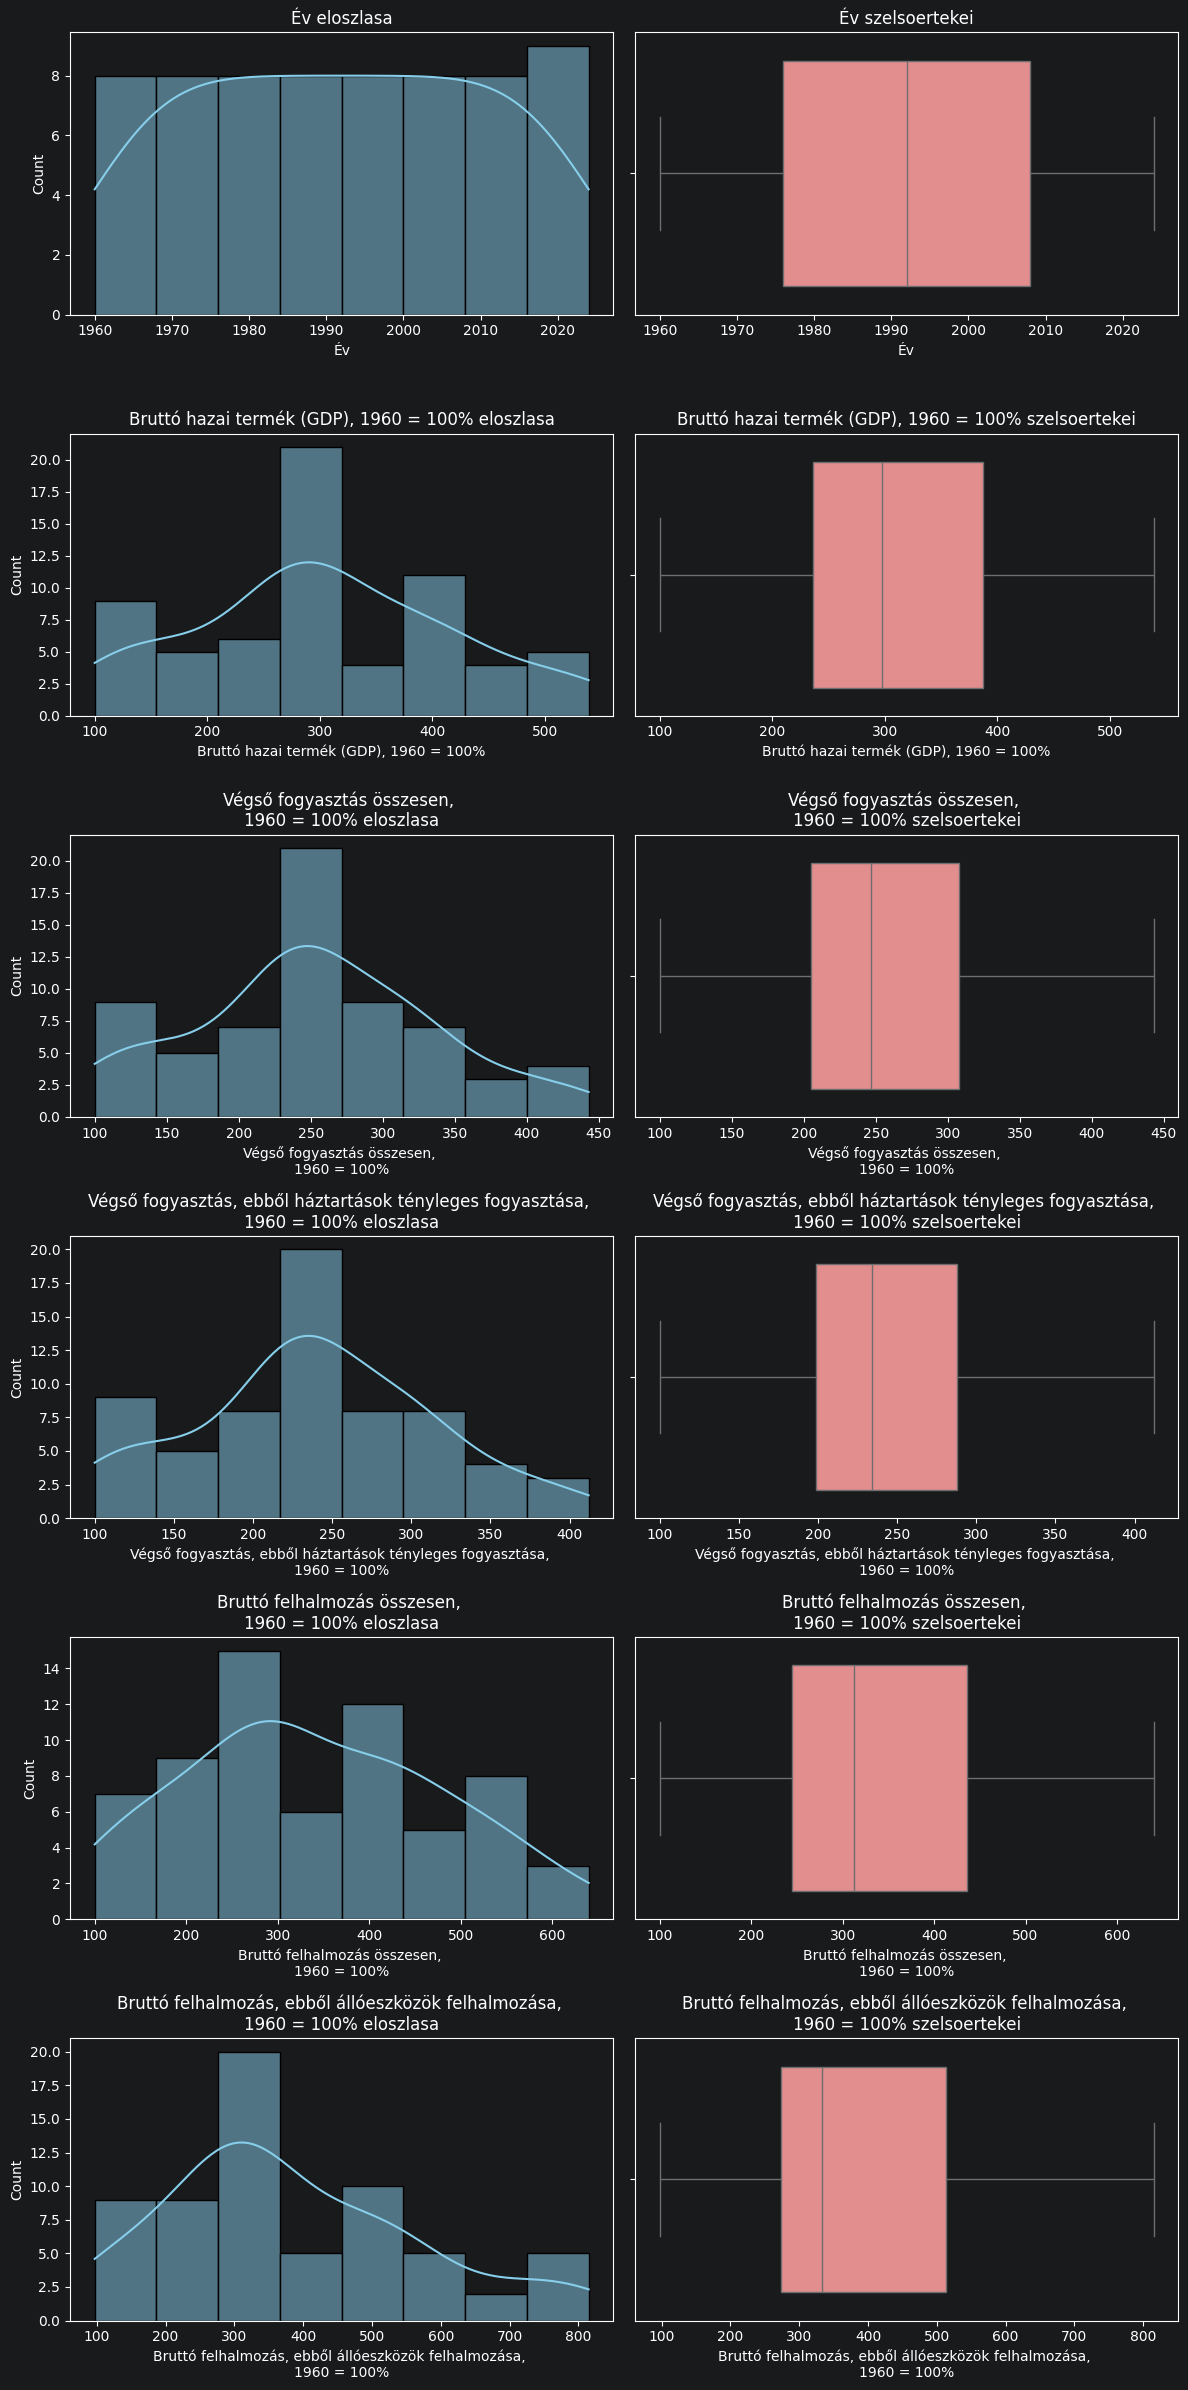

In [661]:
initial_ana4(gdp_df1, "Bruttó hazai termék")


--- Az egy főre jutó reáljövedelem és fogyasztás ELEMZESE ---


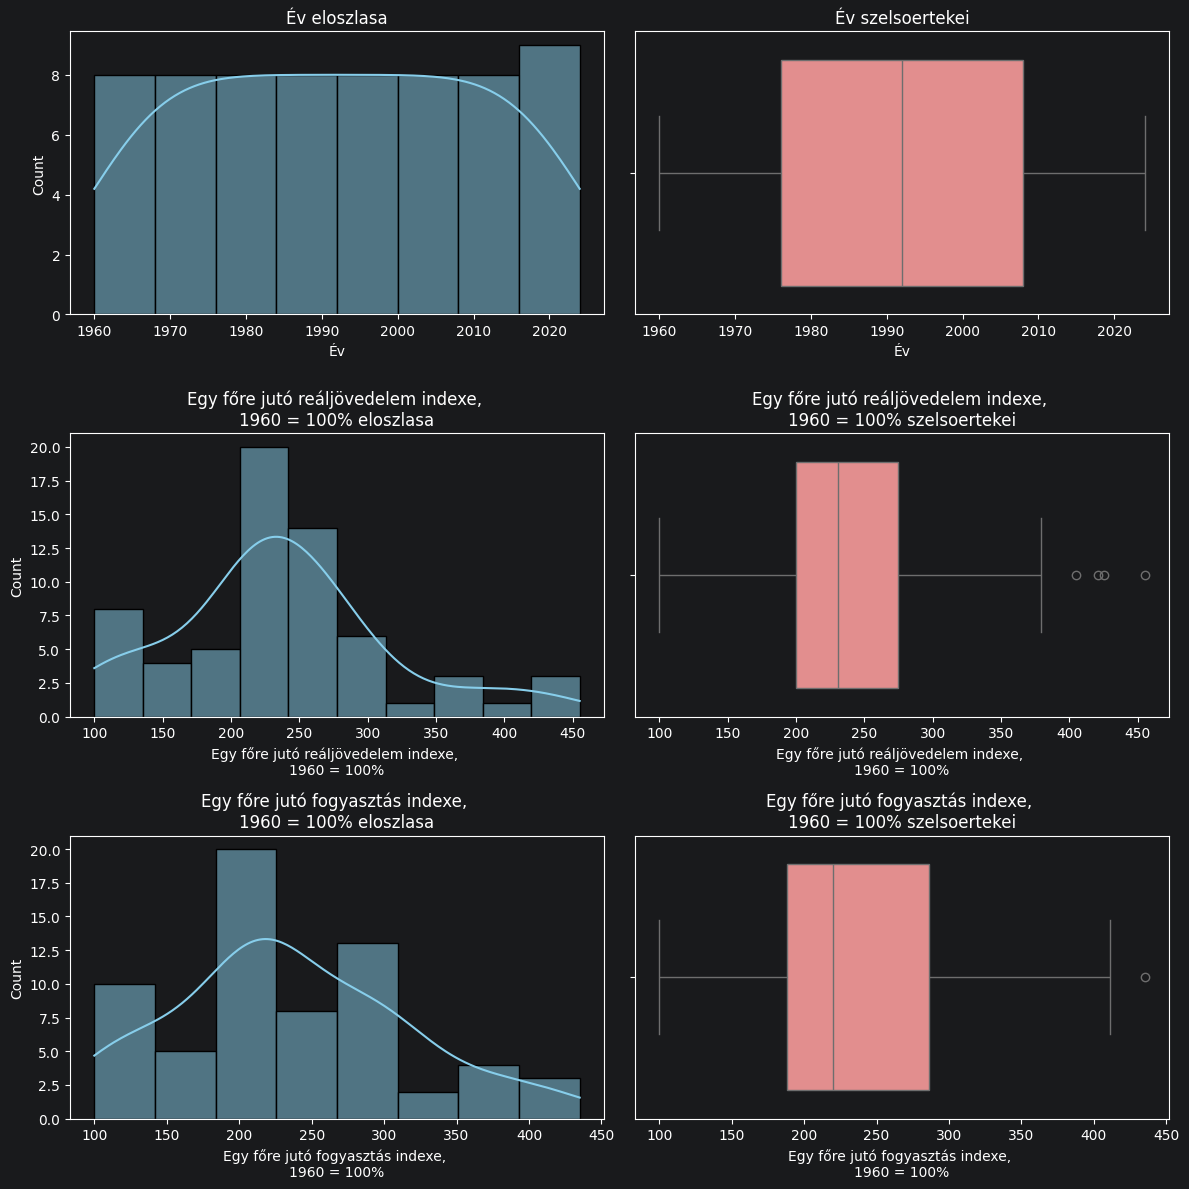

In [662]:
initial_ana4(gdp_df2, "Az egy főre jutó reáljövedelem és fogyasztás")


In [663]:
initial_ana4(gdp_df3, "A háztartások fogyasztási kiadásának volumenindexei rendeltetés szerint")


--- A háztartások fogyasztási kiadásának volumenindexei rendeltetés szerint ELEMZESE ---
Nincs numerikus oszlop a histogramokhoz es boxplotokhoz.


--- Az oktatás főbb, hosszú idősoros adatai ELEMZESE ---


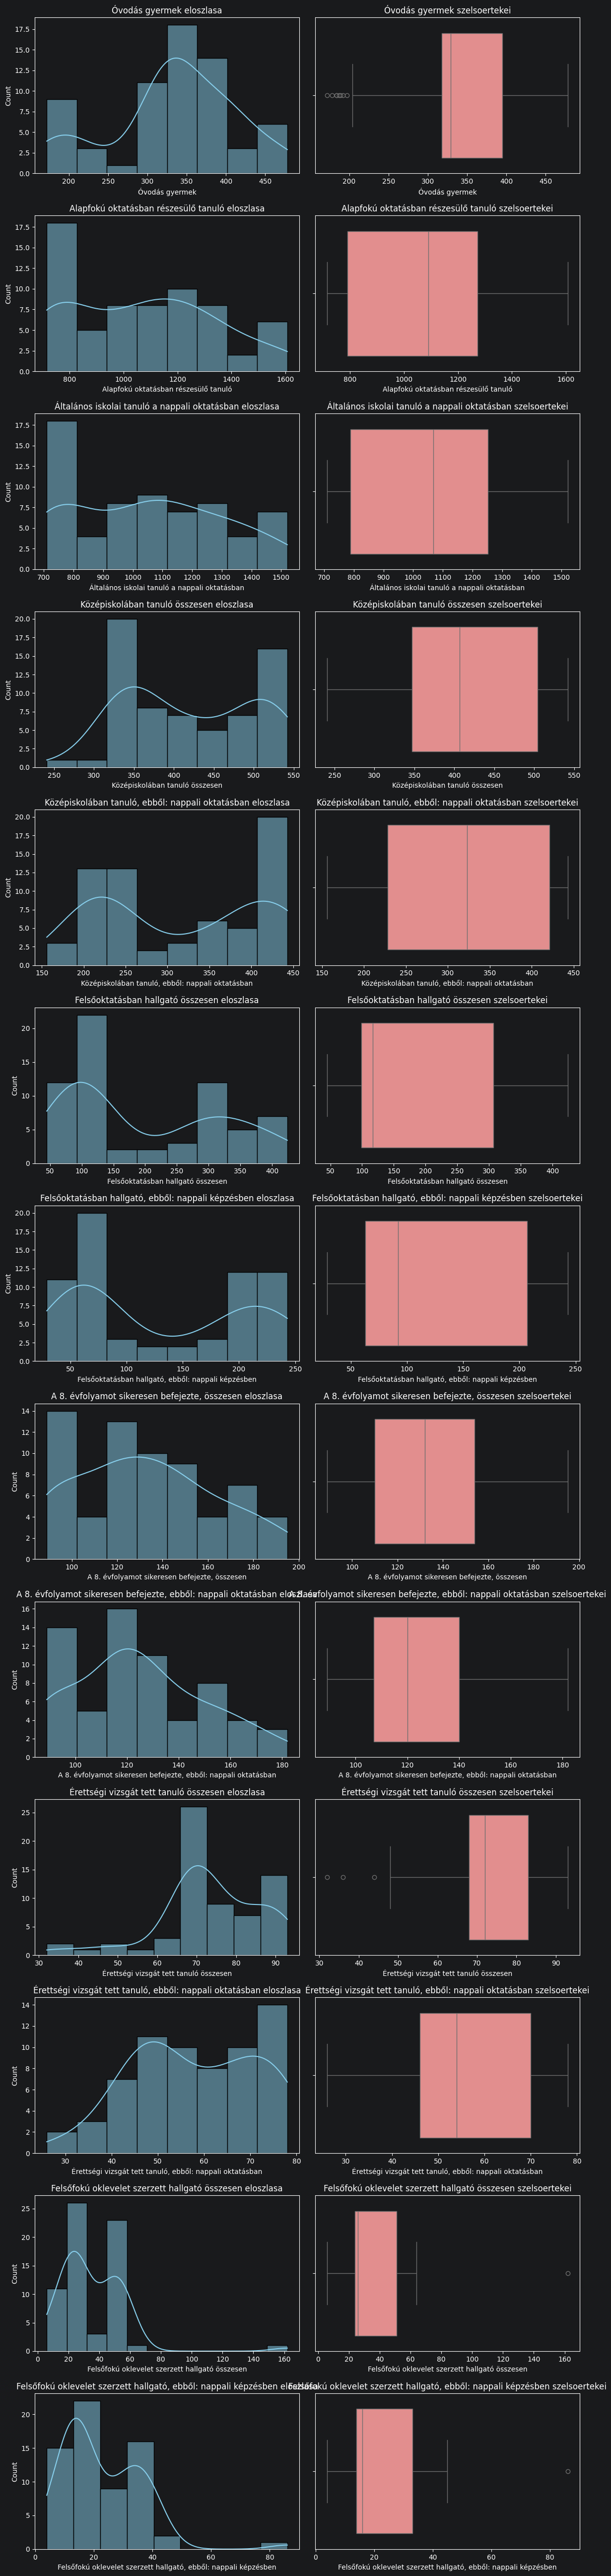

In [664]:
initial_ana4(okt_df1, "Az oktatás főbb, hosszú idősoros adatai")


--- Felsőfokú alap- és mesterképzés ELEMZESE ---


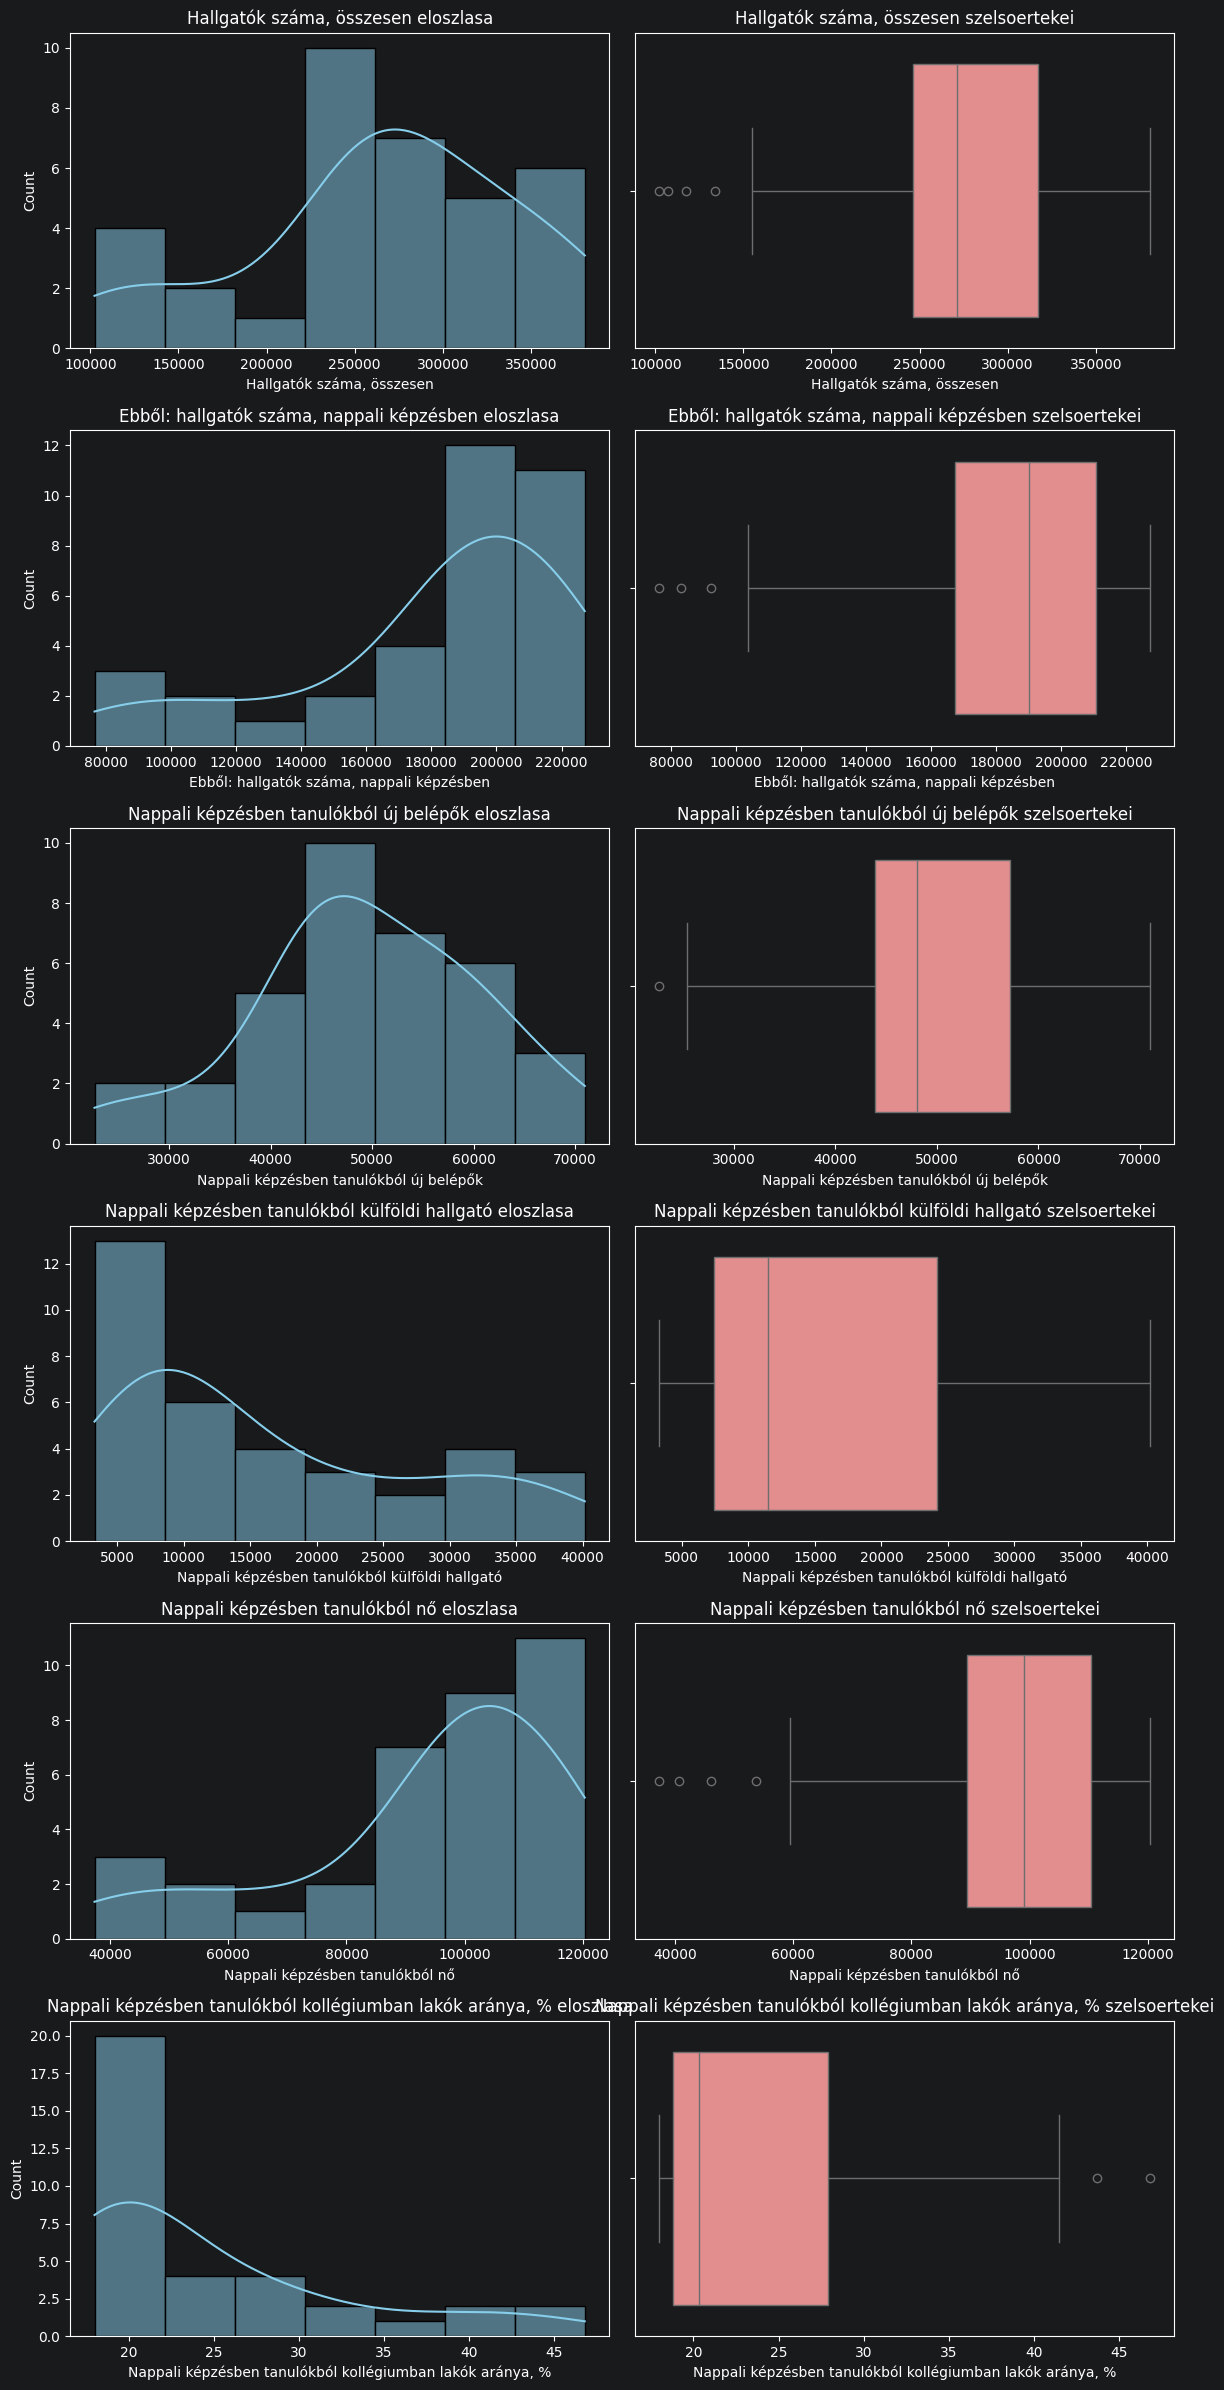

In [665]:
initial_ana4(okt_df2, "Felsőfokú alap- és mesterképzés")


# Futtatás az egyes adatsorokon - CHECK STEP #5 - Korrelációk

--- Bruttó hazai termék ELEMZESE ---


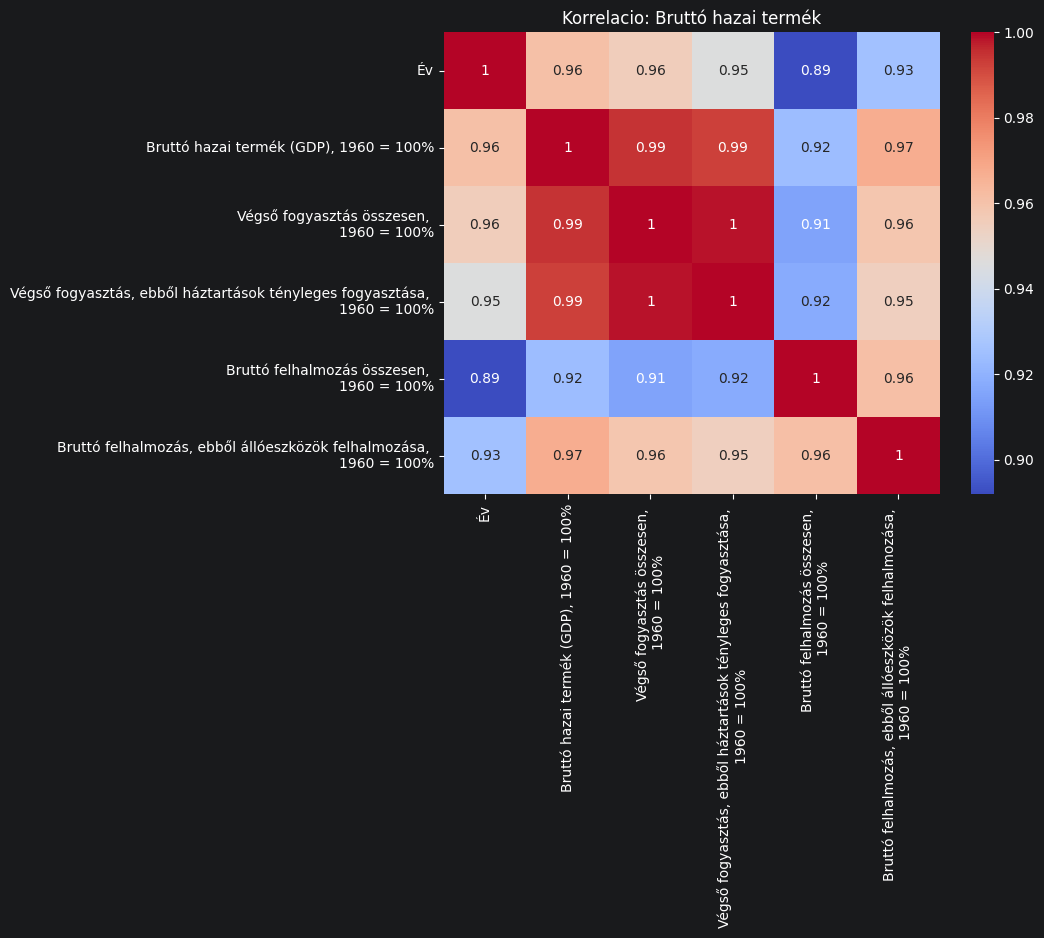

In [666]:
initial_ana5(gdp_df1, "Bruttó hazai termék")


--- Az egy főre jutó reáljövedelem és fogyasztás ELEMZESE ---


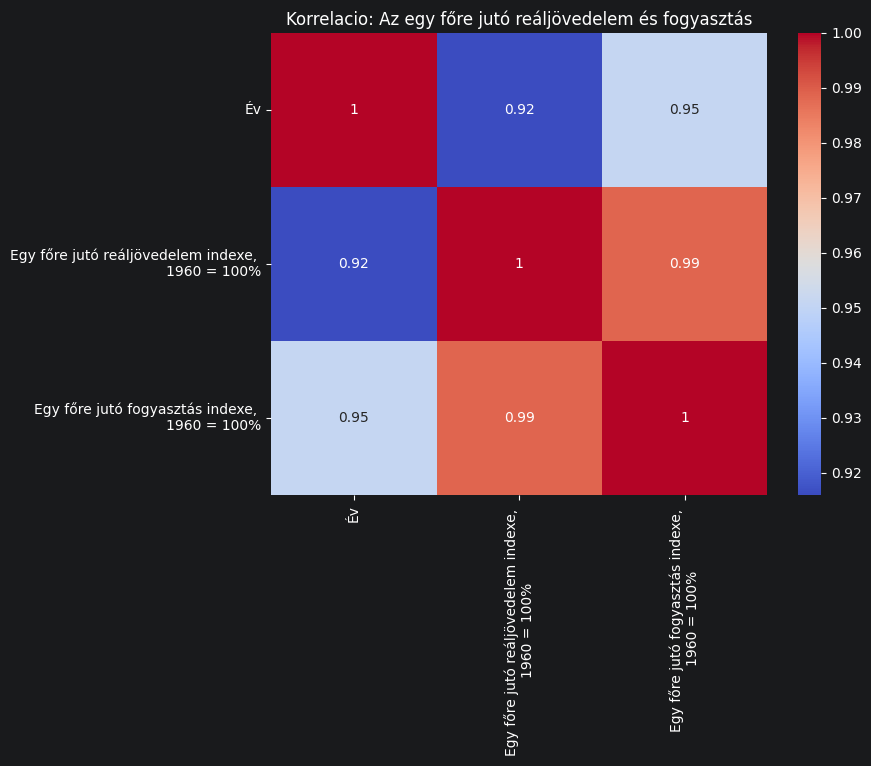

In [667]:
initial_ana5(gdp_df2, "Az egy főre jutó reáljövedelem és fogyasztás")


--- Fogyasztasi fo kategoriak ELEMZESE ---


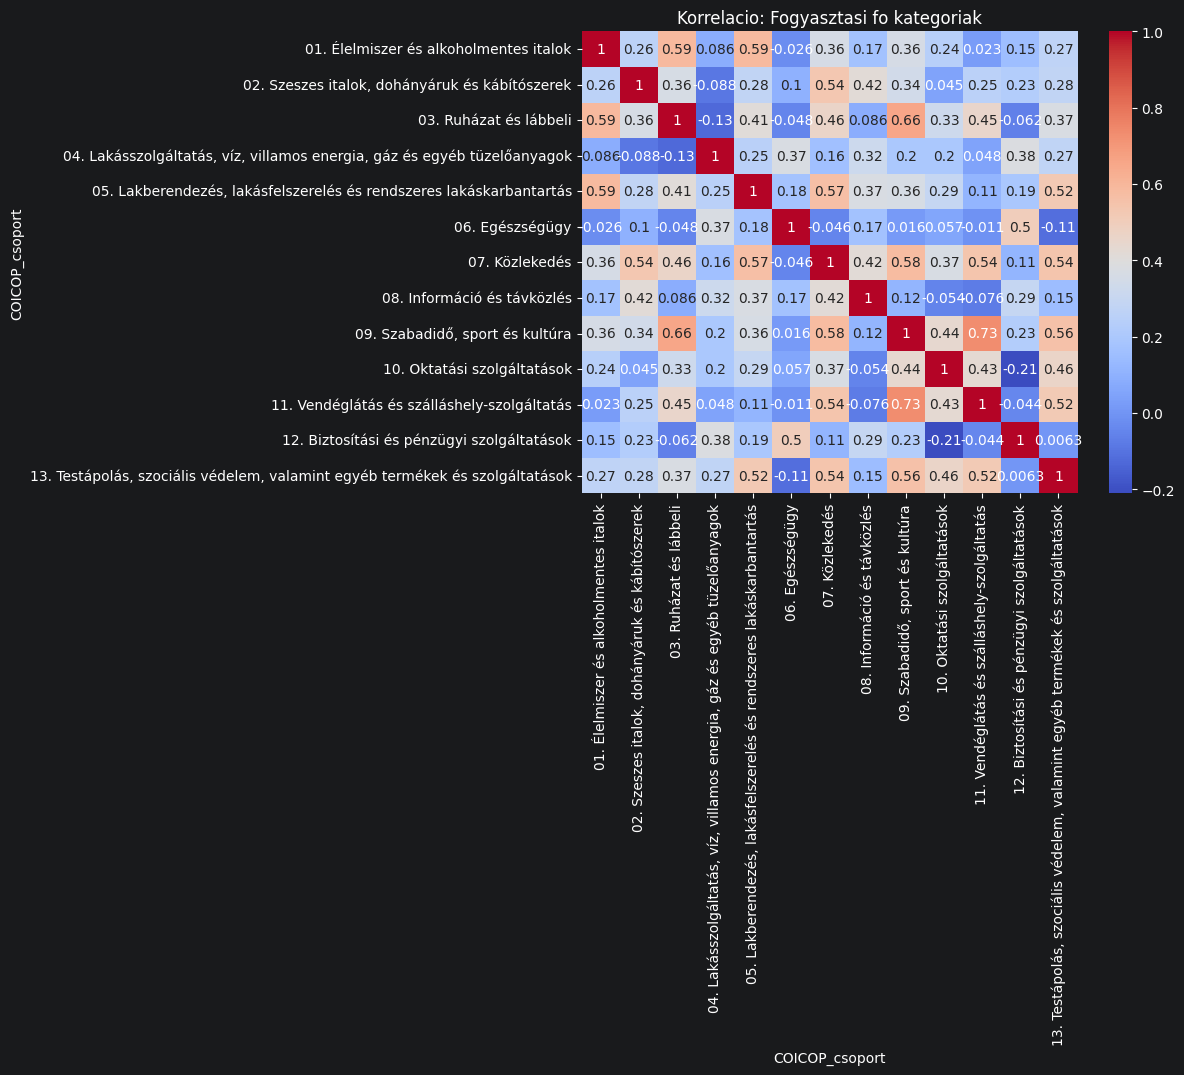

In [668]:
def clean_coicop_data_final(df):
    df_c = df.copy()

    category_col = df_c.columns[0]
    df_c = df_c.rename(columns={category_col: "COICOP_csoport"})
    df_c = df_c.replace(["x", "..", "...", "-", "--"], np.nan)

    for col in df_c.columns[1:]:
        df_c[col] = pd.to_numeric(df_c[col], errors="coerce")

    value_cols = df_c.columns[1:]
    df_c = df_c.dropna(subset=value_cols, how="all")
    return df_c.reset_index(drop=True)

gdp_df3_clean = clean_coicop_data_final(gdp_df3)

# Keep only the main COICOP categories, for example 01., 02., 03.
main_coicop = gdp_df3_clean[gdp_df3_clean["COICOP_csoport"].astype(str).str.match(r"^\d{2}\.\s", na=False)].copy()

# For correlation, categories should be columns and years should be rows.
coicop_corr_df = main_coicop.set_index("COICOP_csoport").T
coicop_corr_df.index.name = "Ev"
coicop_corr_df = coicop_corr_df.dropna(axis=1, how="all")

initial_ana5(coicop_corr_df, "Fogyasztasi fo kategoriak")


--- Az oktatas fobb, hosszu idosoros adatai ELEMZESE ---


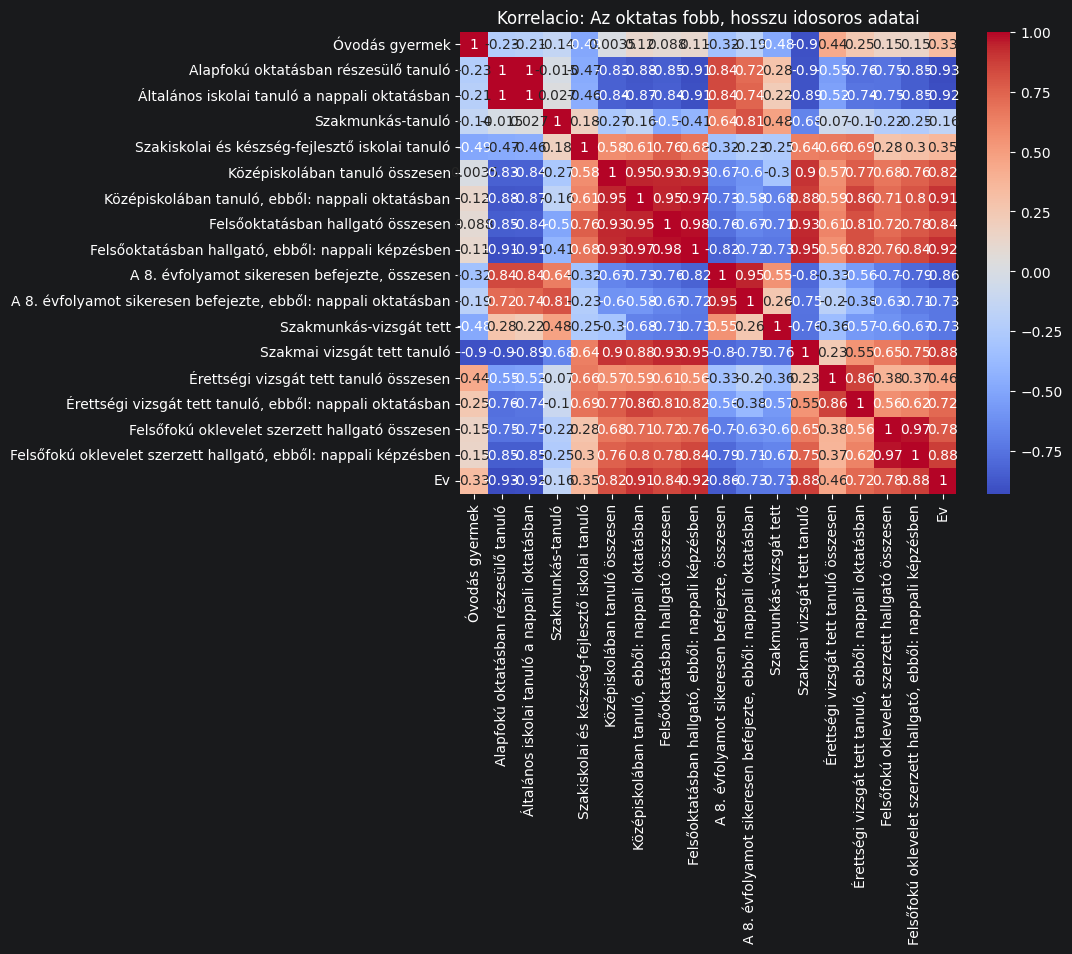

In [669]:
# 1. Evszam tisztitasa
okt_df1['Ev'] = okt_df1.iloc[:, 0].astype(str).str.extract(r'(\d{4})', expand=False).astype(float)

# 2. Specialis KSH karakterek kezelese az egesz DataFrame-ben
okt_df1 = okt_df1.replace(['-', '--'], np.nan)
okt_df1 = okt_df1.replace(r'\.\.', np.nan, regex=True)
okt_df1 = okt_df1.replace(r'\s+', np.nan, regex=True)

# 3. Ezres elvalasztok eltavolitasa, majd szamma alakitas
for col in okt_df1.columns:
    if col != 'Ev' and okt_df1[col].dtype == 'object':
        okt_df1[col] = okt_df1[col].astype(str).str.replace('\xa0', '', regex=False).str.replace(' ', '', regex=False)
        okt_df1[col] = pd.to_numeric(okt_df1[col], errors='coerce')

# 4. Most mar futtathato az elemzes
initial_ana5(okt_df1, "Az oktatas fobb, hosszu idosoros adatai")


--- Felsofoku alap- es mesterkepzes ELEMZESE ---


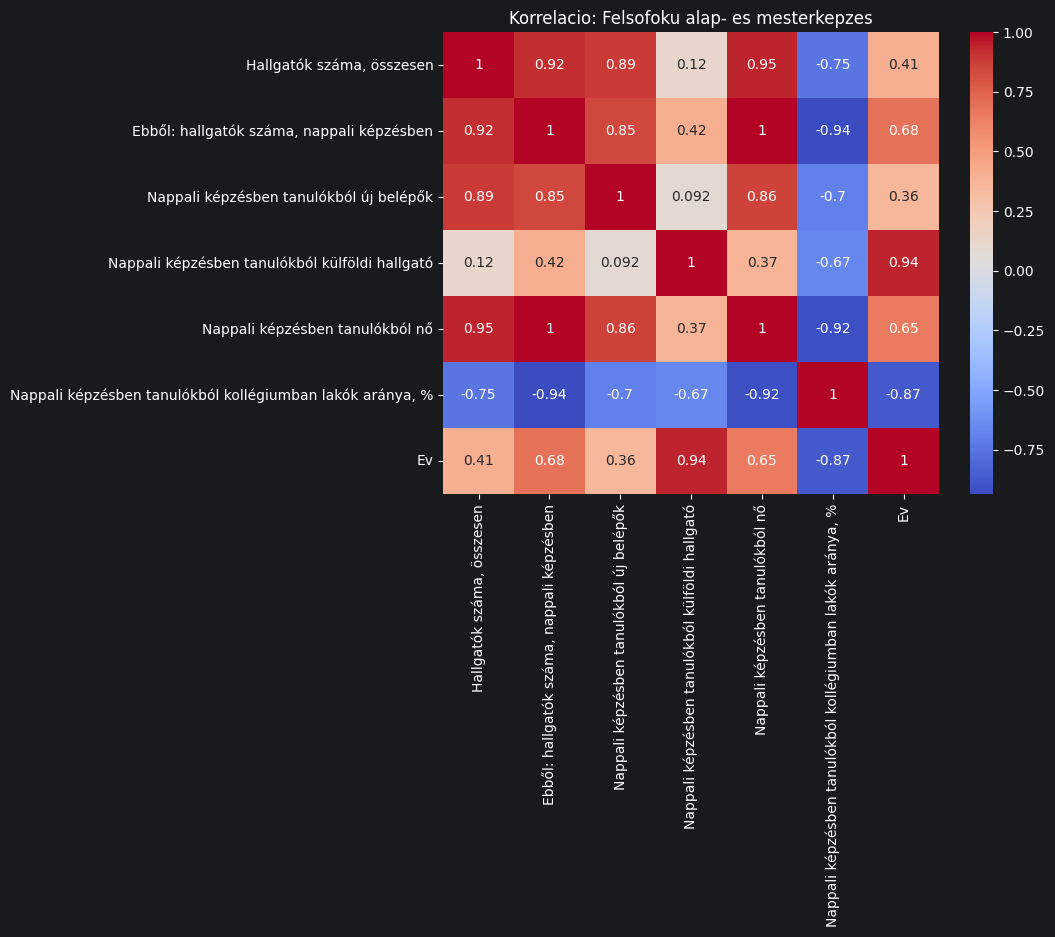

In [670]:
# 1. Evszam tisztitasa
okt_df2['Ev'] = okt_df2.iloc[:, 0].astype(str).str.extract(r'(\d{4})', expand=False).astype(float)

# 2. Specialis KSH karakterek kezelese az egesz DataFrame-ben
okt_df2 = okt_df2.replace(['-', '--'], np.nan)
okt_df2 = okt_df2.replace(r'\.\.', np.nan, regex=True)
okt_df2 = okt_df2.replace(r'\s+', np.nan, regex=True)

# 3. Ezres elvalasztok eltavolitasa, majd szamma alakitas
for col in okt_df2.columns:
    if col != 'Ev' and okt_df2[col].dtype == 'object':
        okt_df2[col] = okt_df2[col].astype(str).str.replace('\xa0', '', regex=False).str.replace(' ', '', regex=False)
        okt_df2[col] = pd.to_numeric(okt_df2[col], errors='coerce')

# 4. Most mar futtathato az elemzes
initial_ana5(okt_df2, "Felsofoku alap- es mesterkepzes")


Tanulságok:
- Az adatsorokban nem talaltunk duplikalt eveket, igy az idosorok egyertelmuen es rendezetten kezelhetok.
- Az altalunk vizsgalt tablazatokban nem talaltunk hianyzo adatokat, ami megkonnyiti a tovabbi tisztitasi es modellezesi lepeseinket.
- A vegso fogyasztas osszesen, a haztartasok tenyleges fogyasztasa, a realjovedelem es az egy fore juto fogyasztas eros egyuttmozgast mutatnak a GDP-vel, illetve egymassal is, ezert a tovabbi modellben nem tartjuk meg oket. Mivel a cel a GDP(t+5) becslese kifejezetten oktatasi valtozok alapjan, ezekre nem lesz szukseg bemeneti adatkent.
- Az oktatasi adatokban az ovodatol a felsofoku kepzesig tobb valtozo is eros egyuttmozgast mutat, ami arra utal, hogy kozuluk több reszben hasonlo informaciot hordoz. Emiatt ezeket az elso valtozatban meg megtartjuk, de a kesobbi feature-valasztas soran varhatoan nem kerul be mindegyik a vegso modellbe.
- Az oktatási és a pénzügyi adatok is erős korrelációban álnak az idővel (évekkel) ezért itt ovatósnak kell majd értelmezni a kapcsolatot, mert nem bizonyitható, hogy egymással is közvetlen a kapcsolat.

# Adatok tisztitasa


- Adattisztitas utan egy kozos modellezesi tablat hozunk letre.
- A bemeneti valtozok az adott ev oktatasi adatai, a celvaltozo pedig az 5 evvel kesobbi GDP.
- Az idosoros jelleg miatt az adatokat idorendben osztjuk fel: 70% train, 15% validation, 15% test.


In [671]:
# A GDP tablaban csak az evet es a GDP oszlopot tartjuk meg.
gdp_target = gdp_df1.iloc[:, [0, 1]].copy()
gdp_target.columns = ["Ev", "GDP"]

# Szam tipusu ev es GDP
gdp_target["Ev"] = pd.to_numeric(gdp_target["Ev"], errors="coerce")
gdp_target["GDP"] = pd.to_numeric(gdp_target["GDP"], errors="coerce")

# Letrehozzuk az 5 evvel kesobbi GDP targetet
gdp_target["Ev"] = gdp_target["Ev"].astype(int)
gdp_target["GDP_t_plus_5"] = gdp_target["GDP"].shift(-5)

display(gdp_target.head())

,Ev,GDP,GDP_t_plus_5
0,1960,100,124.0
1,1961,105,133.0
2,1962,111,143.0
3,1963,117,150.0
4,1964,123,161.0


In [672]:
# Az oktatasi tablaban letrehozzuk az ev oszlopot a tanev kezdoeve alapjan.
okt_clean = okt_df1.copy()

okt_clean["Ev"] = (
    okt_clean.iloc[:, 0]
    .astype(str)
    .str.extract(r"(\d{4})", expand=False)
)

okt_clean["Ev"] = pd.to_numeric(okt_clean["Ev"], errors="coerce")
okt_clean = okt_clean.dropna(subset=["Ev"]).copy()
okt_clean["Ev"] = okt_clean["Ev"].astype(int)

display(okt_clean.head())


,Év,Óvodás gyermek,Alapfokú oktatásban részesülő tanuló,Általános iskolai tanuló a nappali oktatásban,Szakmunkás-tanuló,Szakiskolai és készség-fejlesztő iskolai tanuló,Középiskolában tanuló összesen,"Középiskolában tanuló, ebből: nappali oktatásban",Felsőoktatásban hallgató összesen,"Felsőoktatásban hallgató, ebből: nappali képzésben","A 8. évfolyamot sikeresen befejezte, összesen","A 8. évfolyamot sikeresen befejezte, ebből: nappali oktatásban",Szakmunkás-vizsgát tett,Szakmai vizsgát tett tanuló,Érettségi vizsgát tett tanuló összesen,"Érettségi vizsgát tett tanuló, ebből: nappali oktatásban",Felsőfokú oklevelet szerzett hallgató összesen,"Felsőfokú oklevelet szerzett hallgató, ebből: nappali képzésben",Ev
0,1960/1961,184,1509,1433,125.0,NaN,241,156,45,29,120,107,60.0,NaN,32,26,6,4,1960
1,1961/1962,172,1555,1494,135.0,NaN,284,171,53,35,156,127,65.0,NaN,36,31,6,4,1961
2,1962/1963,178,1605,1521,144.0,NaN,334,187,67,40,171,140,71.0,NaN,44,36,7,5,1962
3,1963/1964,184,1607,1512,151.0,NaN,385,211,82,45,179,148,81.0,NaN,50,36,10,7,1963
4,1964/1965,187,1561,1486,164.0,NaN,417,231,92,49,195,154,76.0,NaN,57,38,11,8,1964


In [673]:
# A regi, szoveges "Év" elhagyjuk, mert mar letrehoztuk a tiszta Ev oszlopot.
okt_clean = okt_clean.drop(columns=[okt_clean.columns[0]])

# Az Ev oszlopon kivul minden oktatasi valtozot numerikussa alakitunk.
for col in okt_clean.columns:
    if col != "Ev":
        okt_clean[col] = (
            okt_clean[col]
            .astype(str)
            .str.replace("\xa0", "", regex=False)
            .str.replace(" ", "", regex=False)
            .str.replace(",", ".", regex=False)
        )
        okt_clean[col] = pd.to_numeric(okt_clean[col], errors="coerce")

display(okt_clean.head())


,Óvodás gyermek,Alapfokú oktatásban részesülő tanuló,Általános iskolai tanuló a nappali oktatásban,Szakmunkás-tanuló,Szakiskolai és készség-fejlesztő iskolai tanuló,Középiskolában tanuló összesen,"Középiskolában tanuló, ebből: nappali oktatásban",Felsőoktatásban hallgató összesen,"Felsőoktatásban hallgató, ebből: nappali képzésben","A 8. évfolyamot sikeresen befejezte, összesen","A 8. évfolyamot sikeresen befejezte, ebből: nappali oktatásban",Szakmunkás-vizsgát tett,Szakmai vizsgát tett tanuló,Érettségi vizsgát tett tanuló összesen,"Érettségi vizsgát tett tanuló, ebből: nappali oktatásban",Felsőfokú oklevelet szerzett hallgató összesen,"Felsőfokú oklevelet szerzett hallgató, ebből: nappali képzésben",Ev
0,184,1509,1433,125.0,NaN,241,156,45,29,120,107,60.0,NaN,32,26,6,4,1960
1,172,1555,1494,135.0,NaN,284,171,53,35,156,127,65.0,NaN,36,31,6,4,1961
2,178,1605,1521,144.0,NaN,334,187,67,40,171,140,71.0,NaN,44,36,7,5,1962
3,184,1607,1512,151.0,NaN,385,211,82,45,179,148,81.0,NaN,50,36,10,7,1963
4,187,1561,1486,164.0,NaN,417,231,92,49,195,154,76.0,NaN,57,38,11,8,1964


In [674]:
# Az oktatasi adatokhoz hozzakapcsoljuk az 5 evvel kesobbi GDP-t.
model_df = okt_clean.merge(
    gdp_target[["Ev", "GDP_t_plus_5"]],
    on="Ev",
    how="left"
)

# Csak azok a sorok maradnak, ahol van 5 evvel kesobbi GDP.
model_df = model_df.dropna(subset=["GDP_t_plus_5"]).copy()

display(model_df.head())
print("A kozos modellezesi tabla merete:", model_df.shape)


,Óvodás gyermek,Alapfokú oktatásban részesülő tanuló,Általános iskolai tanuló a nappali oktatásban,Szakmunkás-tanuló,Szakiskolai és készség-fejlesztő iskolai tanuló,Középiskolában tanuló összesen,"Középiskolában tanuló, ebből: nappali oktatásban",Felsőoktatásban hallgató összesen,"Felsőoktatásban hallgató, ebből: nappali képzésben","A 8. évfolyamot sikeresen befejezte, összesen","A 8. évfolyamot sikeresen befejezte, ebből: nappali oktatásban",Szakmunkás-vizsgát tett,Szakmai vizsgát tett tanuló,Érettségi vizsgát tett tanuló összesen,"Érettségi vizsgát tett tanuló, ebből: nappali oktatásban",Felsőfokú oklevelet szerzett hallgató összesen,"Felsőfokú oklevelet szerzett hallgató, ebből: nappali képzésben",Ev,GDP_t_plus_5
0,184,1509,1433,125.0,NaN,241,156,45,29,120,107,60.0,NaN,32,26,6,4,1960,124.0
1,172,1555,1494,135.0,NaN,284,171,53,35,156,127,65.0,NaN,36,31,6,4,1961,133.0
2,178,1605,1521,144.0,NaN,334,187,67,40,171,140,71.0,NaN,44,36,7,5,1962,143.0
3,184,1607,1512,151.0,NaN,385,211,82,45,179,148,81.0,NaN,50,36,10,7,1963,150.0
4,187,1561,1486,164.0,NaN,417,231,92,49,195,154,76.0,NaN,57,38,11,8,1964,161.0


A kozos modellezesi tabla merete: (60, 19)


In [676]:
# Azokat a valtozokat elhagyjuk a kozos modellezesi tablabol, ahol sok a hianyzo adat.
model_df = model_df.drop(columns=[
    "Szakiskolai és készség-fejlesztő iskolai tanuló",
    "Szakmai vizsgát tett tanuló",
    "Szakmunkás-tanuló",
    "Szakmunkás-vizsgát tett"
])

print("Hianyzo adatok a kozos modellezesi tablaban:")
print(model_df.isna().sum())

print("A kozos modellezesi tabla merete:", model_df.shape)


Hianyzo adatok a kozos modellezesi tablaban:
Óvodás gyermek                                                     0
Alapfokú oktatásban részesülő tanuló                               0
Általános iskolai tanuló a nappali oktatásban                      0
Középiskolában tanuló összesen                                     0
Középiskolában tanuló, ebből: nappali oktatásban                   0
Felsőoktatásban hallgató összesen                                  0
Felsőoktatásban hallgató, ebből: nappali képzésben                 0
A 8. évfolyamot sikeresen befejezte, összesen                      0
A 8. évfolyamot sikeresen befejezte, ebből: nappali oktatásban     0
Érettségi vizsgát tett tanuló összesen                             0
Érettségi vizsgát tett tanuló, ebből: nappali oktatásban           0
Felsőfokú oklevelet szerzett hallgató összesen                     0
Felsőfokú oklevelet szerzett hallgató, ebből: nappali képzésben    0
Ev                                                        

In [677]:
# Idorendbe rendezzuk a kozos modellezesi tablat.
model_df = model_df.sort_values("Ev").reset_index(drop=True)

display(model_df[["Ev", "GDP_t_plus_5"]].head())
display(model_df[["Ev", "GDP_t_plus_5"]].tail())

,Ev,GDP_t_plus_5
0,1960,124.0
1,1961,133.0
2,1962,143.0
3,1963,150.0
4,1964,161.0


,Ev,GDP_t_plus_5
55,2015,483.0
56,2016,518.0
57,2017,539.0
58,2018,535.0
59,2019,539.0


In [678]:
# A kozos modellezesi tablat train, validation es test halmazokra bontjuk.
n = len(model_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:val_end].copy()
test_df = model_df.iloc[val_end:].copy()

print("train:", train_df.shape)
print("validation:", val_df.shape)
print("test:", test_df.shape)


train: (42, 15)
validation: (9, 15)
test: (9, 15)


# Data Exploration

In [679]:
model_df.describe()

,Óvodás gyermek,Alapfokú oktatásban részesülő tanuló,Általános iskolai tanuló a nappali oktatásban,Középiskolában tanuló összesen,"Középiskolában tanuló, ebből: nappali oktatásban",Felsőoktatásban hallgató összesen,"Felsőoktatásban hallgató, ebből: nappali képzésben","A 8. évfolyamot sikeresen befejezte, összesen","A 8. évfolyamot sikeresen befejezte, ebből: nappali oktatásban",Érettségi vizsgát tett tanuló összesen,"Érettségi vizsgát tett tanuló, ebből: nappali oktatásban",Felsőfokú oklevelet szerzett hallgató összesen,"Felsőfokú oklevelet szerzett hallgató, ebből: nappali képzésben",Ev,GDP_t_plus_5
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,333.983333,1098.716667,1079.133333,409.633333,306.550000,192.050000,122.700000,136.066667,127.383333,73.966667,57.733333,32.416667,20.866667,1989.500000,320.683333
std,82.678977,256.596900,240.406539,79.525492,96.099071,122.892736,75.564609,29.590921,24.024769,13.053951,13.927009,15.322844,10.777356,17.464249,106.420575
min,172.000000,724.000000,720.000000,241.000000,156.000000,45.000000,29.000000,89.000000,89.000000,32.000000,26.000000,6.000000,4.000000,1960.000000,124.000000
25%,316.750000,883.750000,880.750000,345.750000,223.500000,99.000000,63.000000,118.000000,114.750000,68.000000,46.000000,23.750000,13.750000,1974.750000,264.000000
50%,331.500000,1123.500000,1079.000000,389.000000,283.000000,108.500000,74.500000,135.500000,123.000000,72.000000,53.500000,26.000000,16.000000,1989.500000,300.500000
75%,395.000000,1298.000000,1282.500000,490.250000,410.250000,298.000000,203.250000,155.250000,142.750000,84.500000,70.000000,50.000000,30.250000,2004.250000,392.500000
max,478.000000,1607.000000,1521.000000,534.000000,443.000000,424.000000,243.000000,195.000000,182.000000,93.000000,78.000000,57.000000,41.000000,2019.000000,539.000000


- A táblának 60 sora van és enm hiányzik adat.
- Az adatokat érdemes lehet majd skálázni, mert nagyon különböző tartományban mozognak

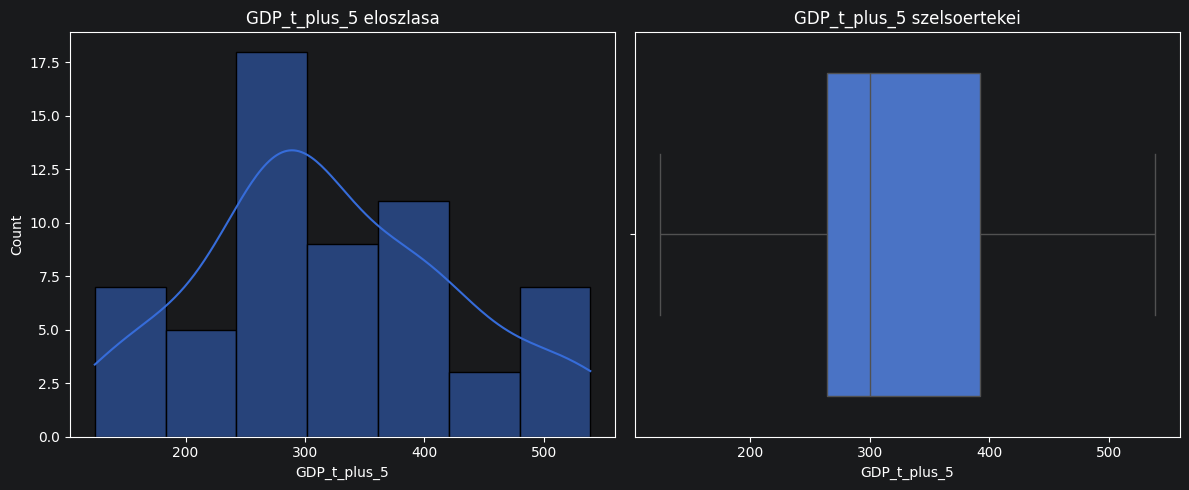

In [680]:
# Megnezzuk a celvaltozo, vagyis a GDP_t_plus_5 eloszlasat es szelsoertekeit.
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(model_df["GDP_t_plus_5"], kde=True)
plt.title("GDP_t_plus_5 eloszlasa")

plt.subplot(1, 2, 2)
sns.boxplot(x=model_df["GDP_t_plus_5"])
plt.title("GDP_t_plus_5 szelsoertekei")

plt.tight_layout()
plt.show()